<a href="https://colab.research.google.com/github/karanamsubbarao/llm-course/blob/main/LLM_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Character Level Tokenizer**

In [6]:
## Parse the URL and download the contents of https://www.gutenberg.org/cache/epub/11/pg11.txt
import os
import requests
import matplotlib.pyplot as plt

#Download the contents of pg11.txt to a file
if not os.path.exists("pg11-contents.txt"):
    url = ("https://www.gutenberg.org/cache/epub/11/pg11.txt")
    file_path = "pg11-contents.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)
raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()


In [7]:
import os
import requests

class CharacterTokenizer:
  def __init__(self,vocab):
    self.unk_token = "<UNK>"
    self.vocab = {v:k for k, v in enumerate(vocab)}
    self.vocab[self.unk_token] = len(vocab)
    self.inv_vocab = {v: k for k, v in self.vocab.items()}

  def encode(self, text) :
    unk_id = self.vocab[self.unk_token]
    return [self.vocab.get(c,unk_id) for c in list(text)]

  def decode(self, ids):
     return ''.join(self.inv_vocab[i] for i in ids)

  def calculate_compression_ratio(self,text,token_ids):
      num_chars = len(text)
      num_tokens = len(token_ids)
      ratio = num_tokens / num_chars
      return ratio

  def calculate_compression_ratio(self,text,token_ids):
      num_chars = len(text)
      num_tokens = len(token_ids)
      ratio = num_tokens / num_chars
      return ratio

  def average_token_length(self,text,token_ids) :
      num_tokens = len(token_ids)
      mean_length = len(text)/num_tokens
      return mean_length

  def vocab_size(self):
     return len(self.vocab)


# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    vocab = list("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!.")  # Vocabulary of all unique characters
    tokenizer = CharacterTokenizer(vocab)
    #Download the contents of pg11.txt to a file
    raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()
    #tokenizer.build_vocabulary(sample_text)
    token_ids = tokenizer.encode(raw_text)
    print("Encoded Tokens:", token_ids)
    decoded_text = tokenizer.decode(token_ids)
    print("decoded_text:", decoded_text)
    print("Compression Ratio", tokenizer.calculate_compression_ratio(raw_text,token_ids))
    print("Average token length", tokenizer.calculate_compression_ratio(raw_text,token_ids))
    print("vocabulary_size", tokenizer.vocab_size())

Encoded Tokens: [45, 7, 4, 54, 41, 17, 14, 9, 4, 2, 19, 54, 32, 20, 19, 4, 13, 1, 4, 17, 6, 54, 4, 27, 14, 14, 10, 54, 14, 5, 54, 26, 11, 8, 2, 4, 54, 18, 54, 26, 3, 21, 4, 13, 19, 20, 17, 4, 18, 54, 8, 13, 54, 48, 14, 13, 3, 4, 17, 11, 0, 13, 3, 54, 54, 54, 54, 54, 54, 45, 7, 8, 18, 54, 4, 27, 14, 14, 10, 54, 8, 18, 54, 5, 14, 17, 54, 19, 7, 4, 54, 20, 18, 4, 54, 14, 5, 54, 0, 13, 24, 14, 13, 4, 54, 0, 13, 24, 22, 7, 4, 17, 4, 54, 8, 13, 54, 19, 7, 4, 54, 46, 13, 8, 19, 4, 3, 54, 44, 19, 0, 19, 4, 18, 54, 0, 13, 3, 54, 12, 14, 18, 19, 54, 14, 19, 7, 4, 17, 54, 15, 0, 17, 19, 18, 54, 14, 5, 54, 19, 7, 4, 54, 22, 14, 17, 11, 3, 54, 0, 19, 54, 13, 14, 54, 2, 14, 18, 19, 54, 0, 13, 3, 54, 22, 8, 19, 7, 54, 0, 11, 12, 14, 18, 19, 54, 13, 14, 54, 17, 4, 18, 19, 17, 8, 2, 19, 8, 14, 13, 18, 54, 22, 7, 0, 19, 18, 14, 4, 21, 4, 17, 53, 54, 50, 14, 20, 54, 12, 0, 24, 54, 2, 14, 15, 24, 54, 8, 19, 54, 54, 6, 8, 21, 4, 54, 8, 19, 54, 0, 22, 0, 24, 54, 14, 17, 54, 17, 4, 54, 20, 18, 4, 54, 8, 19, 

 **White Space Tokenizer**

In [8]:
class WhiteSpaceTokenizer :
    def __init__(self,unk_token="<UNK>"):
      self.unk_token = unk_token
      self.vocab = {unk_token: 0}
      self.inverse_vocab = {0: unk_token}

    # Build vocabulary dynamically
    def build_vocabulary(self, text):
       for token in text.split():
          if token not in self.vocab:
              new_id = len(self.vocab)
              self.vocab[token] = new_id
              self.inverse_vocab[new_id] = token

    # Converts raw text into a list of token IDs."
    def encode(self, text):
      tokens = text.split()
      return [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]

    #Converts a list of Token IDs back into a reconstructed string.
    # Fall back to <unk> if the token_id is invalid or missing

    def decode(self, token_ids):
      tokens = [self.inverse_vocab.get(t_id, "<UNK>") for t_id in token_ids]
      return " ".join(tokens)

    def calculate_compression_ratio(self,text,token_ids):
      num_chars = len(text)
      num_tokens = len(token_ids)
      ratio = num_tokens / num_chars
      return ratio

    def average_token_length(self,text,token_ids) :
      num_tokens = len(token_ids)
      mean_length = len(text)/num_tokens
      return mean_length

    def vocab_size(self) :
      return len(self.vocab)



# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    tokenizer = WhiteSpaceTokenizer()
    raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()
    tokenizer.build_vocabulary(raw_text)

    token_ids = tokenizer.encode(raw_text)
    print("Encoded Tokens:", token_ids)

    decoded_text = tokenizer.decode(token_ids)
    print("decoded_text:", decoded_text)

    print("Compression Ratio", tokenizer.calculate_compression_ratio(raw_text,token_ids))
    print("Average token length", tokenizer.calculate_compression_ratio(raw_text,token_ids))
    print("vocabulary_size", tokenizer.vocab_size())



Encoded Tokens: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 4, 11, 12, 13, 14, 5, 15, 16, 8, 13, 17, 18, 19, 20, 21, 22, 5, 13, 23, 24, 25, 26, 19, 27, 28, 25, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 36, 40, 13, 41, 5, 13, 2, 3, 42, 43, 27, 44, 4, 38, 45, 24, 46, 47, 48, 49, 50, 51, 8, 13, 17, 52, 48, 53, 54, 55, 56, 13, 57, 5, 13, 58, 59, 48, 49, 51, 60, 61, 44, 62, 63, 6, 7, 8, 9, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 69, 77, 78, 79, 80, 81, 82, 19, 83, 84, 85, 86, 87, 19, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 90, 101, 102, 7, 8, 9, 103, 65, 66, 93, 104, 105, 106, 107, 108, 109, 110, 111, 13, 112, 109, 113, 1, 114, 5, 115, 109, 116, 117, 118, 19, 119, 120, 121, 109, 122, 1, 123, 124, 8, 119, 125, 126, 109, 127, 128, 129, 119, 130, 109, 131, 132, 19, 133, 109, 134, 117, 135, 136, 109, 137, 1, 138, 139, 109, 140, 1, 141, 142, 143, 109, 144, 1, 145, 146, 109, 147, 148, 149, 13, 150, 109, 151, 102, 152, 109, 110, 111, 13, 112, 153, 154, 155, 55, 156, 157, 158, 5, 159

**TiktokenTokenizer**

In [9]:
import tiktoken

class MyTiktokenTokenizer :
    def __init__(self,vocabulary=None):
      self.tiktokenizer = tiktoken.get_encoding("gpt2")

    # Converts raw text into a list of token IDs."
    def encode(self, text):
      return self.tiktokenizer.encode(text)

    #Converts a list of Token IDs back into a reconstructed string.
    # Fall back to <unk> if the token_id is invalid or missing
    def decode(self, token_ids):
      return self.tiktokenizer.decode(token_ids)


    def calculate_compression_ratio(self,text,token_ids):
      num_chars = len(text)
      num_tokens = len(token_ids)
      ratio = num_tokens / num_chars
      return ratio

    def average_token_length(self,text,token_ids) :
      num_tokens = len(token_ids)
      mean_length = len(text)/num_tokens
      return mean_length

    def vocab_size(self) :
      return self.tiktokenizer.n_vocab

# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    tokenizer = MyTiktokenTokenizer()

    #Download the contents of pg11.txt to a file
    raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()
    #tokenizer.build_vocabulary(sample_text)

    token_ids = tokenizer.encode(raw_text)
    print("Encoded Tokens:", token_ids)

    decoded_text = tokenizer.decode(token_ids)
    print("decoded_text:", decoded_text)

    print("Compression Ratio", tokenizer.calculate_compression_ratio(raw_text,token_ids))

    print("Average token length", tokenizer.calculate_compression_ratio(raw_text,token_ids))

    print("vocabulary_size", tokenizer.vocab_size())


Encoded Tokens: [464, 4935, 20336, 46566, 286, 14862, 338, 15640, 287, 42713, 198, 220, 220, 220, 220, 198, 1212, 46566, 318, 329, 262, 779, 286, 2687, 6609, 287, 262, 1578, 1829, 290, 198, 1712, 584, 3354, 286, 262, 995, 379, 645, 1575, 290, 351, 2048, 645, 8733, 198, 10919, 15485, 13, 921, 743, 4866, 340, 11, 1577, 340, 1497, 393, 302, 12, 1904, 340, 739, 262, 2846, 198, 1659, 262, 4935, 20336, 13789, 3017, 351, 428, 46566, 393, 2691, 198, 265, 7324, 13, 70, 19028, 13, 2398, 13, 1002, 345, 389, 407, 5140, 287, 262, 1578, 1829, 11, 198, 5832, 481, 423, 284, 2198, 262, 3657, 286, 262, 1499, 810, 345, 389, 5140, 198, 19052, 1262, 428, 46566, 13, 198, 198, 19160, 25, 14862, 338, 15640, 287, 42713, 198, 198, 13838, 25, 10174, 21298, 628, 198, 220, 220, 220, 220, 220, 220, 220, 220, 198, 26362, 3128, 25, 2795, 2681, 11, 3648, 685, 68, 10482, 1303, 1157, 60, 198, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 4042, 2904, 6153, 25, 2795, 2608, 11, 32190, 198, 198,

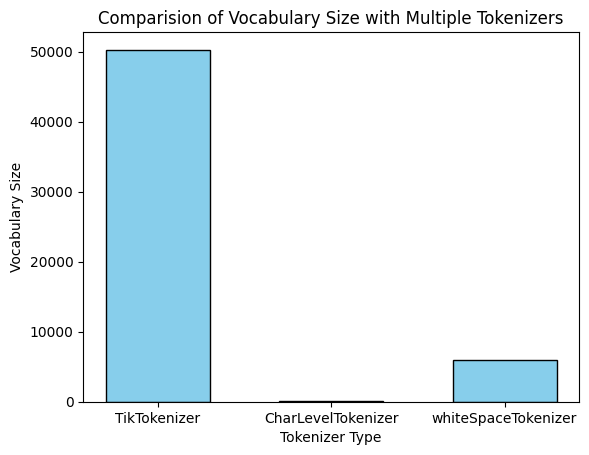

In [10]:
import os
import requests
import matplotlib.pyplot as plt

#Download the contents of pg11.txt to a file
if not os.path.exists("pg11-contents.txt"):
    url = ("https://www.gutenberg.org/cache/epub/11/pg11.txt")
    file_path = "pg11-contents.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)
raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()

#MyTiktokenTokenizer
tiktokenizer = MyTiktokenTokenizer()
token_ids = tiktokenizer.encode(raw_text)
tiktokenizer_compression_ratio = tiktokenizer.calculate_compression_ratio(raw_text,token_ids)
#print('tiktokenizer_compression_ratio',tiktokenizer_compression_ratio)
tiktokenizer_avg_token_length = tiktokenizer.average_token_length(raw_text,token_ids)
#print('tiktokenizer_avg_token_length',tiktokenizer_avg_token_length)
tiktokenizer_vocab_size = tiktokenizer.vocab_size()
#print('tiktokenizer_vocab_size',tiktokenizer_vocab_size)


#White Space Tokenizer
whiteSpaceTokenizer = WhiteSpaceTokenizer()
whiteSpaceTokenizer.build_vocabulary(raw_text)
white_space_token_ids = whiteSpaceTokenizer.encode(raw_text)
white_space_tokenizer_compression_ratio = whiteSpaceTokenizer.calculate_compression_ratio(raw_text,white_space_token_ids)
#print('white_space_tokenizer_compression_ratio',white_space_tokenizer_compression_ratio)
white_space_tokenizer_avg_token_length = whiteSpaceTokenizer.average_token_length(raw_text,white_space_token_ids)
#print('white_space_tokenizer_avg_token_length',white_space_tokenizer_avg_token_length)
white_space_tokenizer_vocab_size = whiteSpaceTokenizer.vocab_size()
#print('white_space_tokenizer_vocab_size',white_space_tokenizer_vocab_size)


#Character Level Tokenizer
vocab = list("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!.")  # Vocabulary of all unique characters
charTokenizer = CharacterTokenizer(vocab)
char_token_ids=charTokenizer.encode(raw_text)
charLeveltokenizer_compression_ratio = charTokenizer.calculate_compression_ratio(raw_text,char_token_ids)
#print(f'charLeveltokenizer_compression_ratio',charLeveltokenizer_compression_ratio)
charLeveltokenizer_avg_token_length = charTokenizer.average_token_length(raw_text,char_token_ids)
#print('charLeveltokenizer_avg_token_length',charLeveltokenizer_avg_token_length)
charLeveltokenizer_vocab_size = charTokenizer.vocab_size()
#print('charLeveltokenizer_vocab_size',charLeveltokenizer_vocab_size)

values =[tiktokenizer_vocab_size,charLeveltokenizer_vocab_size,white_space_tokenizer_vocab_size]
categories = ['TikTokenizer', 'CharLevelTokenizer','whiteSpaceTokenizer']
 #Create vertical bar chart
plt.bar(categories, values, color='skyblue', edgecolor='black', width=0.6)

# Labels and title
plt.xlabel('Tokenizer Type')
plt.ylabel('Vocabulary Size')
plt.title('Comparision of Vocabulary Size with Multiple Tokenizers')

# Display the plot
plt.show()



Fundamental Trade off between vocabulary size and sequence length .

**Large Vocabulary: **  
   Input Text will be broken into fewer tokens resulting in shorter sequences. Fewer Sequences will be Linguistically intuitive and readable by humans. Processing will be faster for Short Sequences

** Small Vocabulary: **

Input text will be split into large number of small tokens, resulting in longer sequences (5-10x longer) and it will become computationally expensive and struggle to maintain context over long spans.
Small vocabulary(Character Level) also lack semantic meaning